In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.metrics import accuracy_score

#**Generating Synthatic Data:**

In [4]:
X, y = make_moons(n_samples = 1000, noise = 0.2, random_state = 42)

In [5]:
X

array([[-0.11166654,  0.52022374],
       [ 1.14264982, -0.34257734],
       [ 0.79555796, -0.01144231],
       ...,
       [ 1.72760808, -0.42882943],
       [-1.01448644,  0.13522904],
       [ 0.77438101,  0.63428493]])

In [6]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [7]:
y = y.reshape(-1,1)

In [8]:
y

array([[1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
    

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state = 42)

#**Building a Sequencial Model with Different Actiavtions**

In [22]:
#Building Seq Model with Linear Activation
def build_linear_model():
  model = Sequential([Dense(4, activation = 'linear',input_dim = 2),# Giving 4 Layers
                     Dense(1,activation = 'sigmoid') # Output Layer for Binary Classification
                     ])

  model.compile(optimizer = Adam(learning_rate = 0.01), loss = 'binary_crossentropy',metrics = ['accuracy'])
  return model



#Building Seq Modle with sigmoid Activation
def build_relu_model():
  model = Sequential([
      Dense(4,activation = 'relu',input_dim = 2), #First Layer with ReLU Activation
      Dense(1,activation = 'sigmoid') # Output Layer for Binary Classification
  ])
  model.compile(optimizer = Adam(learning_rate = 0.01), loss = 'binary_crossentropy',metrics = ['accuracy'])
  return model


#**Train and Evaluating the Models**

In [25]:
def train_and_evaluate(model,X_train,X_test,y_train,y_test, epochs = 58 , batch_size = 32):
  # Epochs: How many times we repeat the train
  # batch_size : How many input size we need to take out of the 1000 samples in 1 epoch


  # Training part:
  model.fit(X_train,y_train,epochs = epochs, batch_size = batch_size,verbose =2)
  y_pred = (model.predict(X_test)>0.5).astype(int)


  # Evaluation part:
  accuracy = accuracy_score(y_test,y_pred)
  return accuracy, y_pred

#**Initializing and Training-Evaluating Models:**

In [26]:
linear_model = build_linear_model()
relu_model = build_relu_model()


# Train and Evaluate linear model:
print("Training Linear Model....")
linear_accuracy, linear_preds = train_and_evaluate(linear_model,X_train,X_test,y_train,y_test)
print(f"Accuracy with Linear Activation: {linear_accuracy}")




# Train and Evaluate relu model:
print("Training ReLU Model....")
relu_accuracy,relu_preds = train_and_evaluate(relu_model,X_train,X_test,y_train,y_test)
print(f"Accuracy with relu activation: {relu_accuracy}")

Training Linear Model....
Epoch 1/58
25/25 - 1s - 51ms/step - accuracy: 0.6313 - loss: 0.6076
Epoch 2/58
25/25 - 0s - 6ms/step - accuracy: 0.7412 - loss: 0.4680
Epoch 3/58
25/25 - 0s - 3ms/step - accuracy: 0.7900 - loss: 0.4024
Epoch 4/58
25/25 - 0s - 3ms/step - accuracy: 0.8250 - loss: 0.3552
Epoch 5/58
25/25 - 0s - 6ms/step - accuracy: 0.8500 - loss: 0.3218
Epoch 6/58
25/25 - 0s - 4ms/step - accuracy: 0.8612 - loss: 0.3018
Epoch 7/58
25/25 - 0s - 5ms/step - accuracy: 0.8687 - loss: 0.2920
Epoch 8/58
25/25 - 0s - 4ms/step - accuracy: 0.8650 - loss: 0.2895
Epoch 9/58
25/25 - 0s - 4ms/step - accuracy: 0.8700 - loss: 0.2870
Epoch 10/58
25/25 - 0s - 3ms/step - accuracy: 0.8687 - loss: 0.2868
Epoch 11/58
25/25 - 0s - 3ms/step - accuracy: 0.8687 - loss: 0.2875
Epoch 12/58
25/25 - 0s - 3ms/step - accuracy: 0.8675 - loss: 0.2868
Epoch 13/58
25/25 - 0s - 3ms/step - accuracy: 0.8687 - loss: 0.2863
Epoch 14/58
25/25 - 0s - 4ms/step - accuracy: 0.8650 - loss: 0.2870
Epoch 15/58
25/25 - 0s - 3ms/s

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy with relu activation: 0.98


#**Visualizing Decision Boundaries:**

In [27]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = (Z > 0.5).astype(int).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), edgecolor="k")
    plt.title(title)
    plt.show()


Visualizing decision boundaries...
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


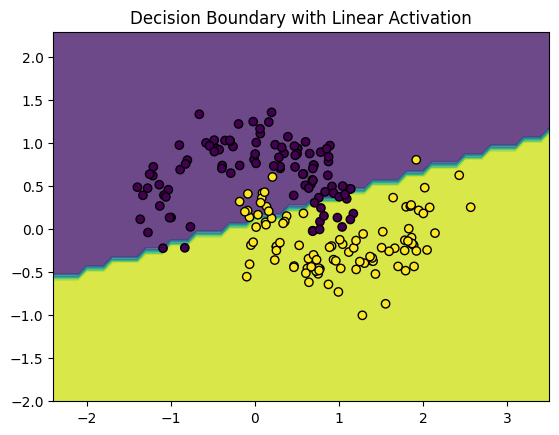

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


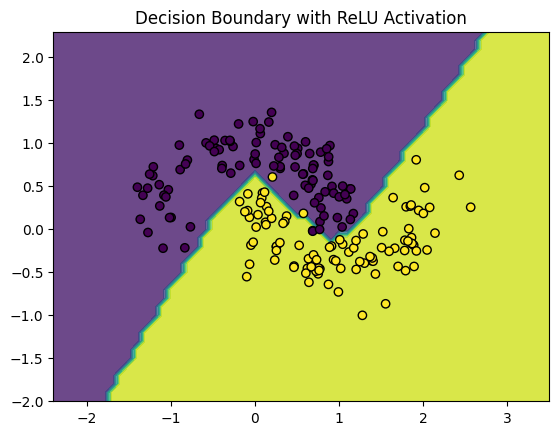

In [28]:
# Plot decision boundaries
print("\nVisualizing decision boundaries...")
plot_decision_boundary(linear_model, X_test, y_test, "Decision Boundary with Linear Activation")
plot_decision_boundary(relu_model, X_test, y_test, "Decision Boundary with ReLU Activation")